# Part 9 — Chris
## NBA Advanced Stats via NBA API → Over/Under Model

This notebook:
1. **Pulls basic team game logs** (original cell — kept for reference)
2. **Pulls advanced team game logs** for all seasons 2007-08 → 2024-25 using `TeamGameLogs(measure_type='Advanced')`
3. **Engineers rolling features** (L5 / L10 windows, lagged 1 game, within-season only)
4. **Merges** advanced features with the betting data from FINALPROJECT.ipynb
5. **Trains Ridge, Gradient Boosting, and RBF+Ridge** models and evaluates ROI at multiple thresholds

---
## Section 0 — Original Basic Game Log Pull (Reference)
This was the original cell in Part 9 Chris. Kept for reference.

In [2]:
from nba_api.stats.endpoints import leaguegamelog
import pandas as pd
import time

# 1. Define the seasons you want (NBA API uses this format)
seasons = [
    '2018-19', '2019-20', '2020-21', 
    '2021-22', '2022-23', '2023-24', '2024-25'
]

frames = []

for season in seasons:
    print(f"Fetching data for {season}...")
    try:
        # player_or_team_abbreviation='T' tells the API we want TEAM game logs, not players
        gamelog = leaguegamelog.LeagueGameLog(
            season=season, 
            player_or_team_abbreviation='T'
        )
        
        # Get the data as a pandas DataFrame
        df = gamelog.get_data_frames()[0]
        
        # Add a column so you know which season it belongs to
        df['SEASON_STR'] = season
        frames.append(df)
        
        # Be polite to the NBA API to avoid a timeout (1-2 seconds is usually fine)
        time.sleep(2)
        
    except Exception as e:
        print(f"Error on {season}: {e}")

# 2. Combine all seasons into one massive DataFrame
if frames:
    full_df = pd.concat(frames, ignore_index=True)
    print("Success! Total games pulled:", len(full_df))
    
display(full_df.head())
display(full_df.tail())
print(full_df.shape)
for col in full_df.columns:
    print(col)

Fetching data for 2018-19...
Fetching data for 2019-20...
Fetching data for 2020-21...
Fetching data for 2021-22...
Fetching data for 2022-23...
Fetching data for 2023-24...
Fetching data for 2024-25...
Success! Total games pulled: 16578


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON_STR
0,22018,1610612744,GSW,Golden State Warriors,0021800002,2018-10-16,GSW vs. OKC,W,240,42,...,58,28,7,7,21,29,108,8,1,2018-19
1,22018,1610612738,BOS,Boston Celtics,0021800001,2018-10-16,BOS vs. PHI,W,240,42,...,55,21,7,5,15,20,105,18,1,2018-19
2,22018,1610612760,OKC,Oklahoma City Thunder,0021800002,2018-10-16,OKC @ GSW,L,240,33,...,45,21,12,6,15,21,100,-8,1,2018-19
3,22018,1610612755,PHI,Philadelphia 76ers,0021800001,2018-10-16,PHI @ BOS,L,240,34,...,47,18,8,5,16,20,87,-18,1,2018-19
4,22018,1610612737,ATL,Atlanta Hawks,0021800007,2018-10-17,ATL @ NYK,L,240,41,...,45,19,7,3,24,30,107,-19,1,2018-19


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON_STR
16573,22024,1610612747,LAL,Los Angeles Lakers,0022401199,2025-04-13,LAL @ POR,L,240,31,...,42,21,9,11,21,21,81,-28,1,2024-25
16574,22024,1610612759,SAS,San Antonio Spurs,0022401197,2025-04-13,SAS vs. TOR,W,240,43,...,50,22,11,2,12,13,125,7,1,2024-25
16575,22024,1610612763,MEM,Memphis Grizzlies,0022401194,2025-04-13,MEM vs. DAL,W,240,52,...,53,31,13,7,12,15,132,35,1,2024-25
16576,22024,1610612738,BOS,Boston Celtics,0022401187,2025-04-13,BOS vs. CHA,W,240,35,...,49,22,12,6,13,14,93,7,1,2024-25
16577,22024,1610612756,PHX,Phoenix Suns,0022401200,2025-04-13,PHX @ SAC,L,240,40,...,37,28,6,1,13,9,98,-11,1,2024-25


(16578, 30)
SEASON_ID
TEAM_ID
TEAM_ABBREVIATION
TEAM_NAME
GAME_ID
GAME_DATE
MATCHUP
WL
MIN
FGM
FGA
FG_PCT
FG3M
FG3A
FG3_PCT
FTM
FTA
FT_PCT
OREB
DREB
REB
AST
STL
BLK
TOV
PF
PTS
PLUS_MINUS
VIDEO_AVAILABLE
SEASON_STR


---
## Section 1 — Pull Advanced Stats via NBA API

We switch from `LeagueGameLog` (basic stats) to **`TeamGameLogs(measure_type='Advanced')`**, which returns per-game advanced box scores including:

| Column | What it measures | Why it helps O/U |
|---|---|---|
| `PACE` | Possessions per 48 min | **Directly drives scoring volume** |
| `OFF_RATING` | Points per 100 possessions (offense) | Combined with PACE → expected pts |
| `DEF_RATING` | Points per 100 possessions (defense) | Determines how well opponent scores |
| `EFG_PCT` | Effective FG% (3-ptrs weighted 1.5x) | Shooting efficiency → scoring output |
| `TS_PCT` | True Shooting % (incl. free throws) | Most complete efficiency metric |
| `TM_TOV_PCT` | Turnover rate | Turnovers kill possessions → fewer pts |
| `OREB_PCT` | Offensive rebound rate | Extra possessions = more scoring chances |
| `POSS` | Total possessions in game | Direct possession count |
| `NET_RATING` | OFF_RATING − DEF_RATING | Overall team quality |
| `PIE` | Player Impact Estimate | Composite efficiency metric |

**Key derived features we create:**
- `pace_sum` = H_PACE + A_PACE → best pace predictor
- `expected_total_adv` = pace × avg_efficiency / 100 × 96 → physics-based total estimate
- `off_vs_def_gap` = (H_OFF − A_DEF) + (A_OFF − H_DEF) → how each offense beats its defense
- `efg_sum`, `tov_sum`, `oreb_sum` → combined shooting / turnover / rebounding

In [9]:
# ============================================================
# CELL 1: Pull Advanced Team Game Logs for All Seasons
# ============================================================
from nba_api.stats.endpoints import teamgamelogs
import pandas as pd
import time
import os

ALL_SEASONS = [
    '2007-08', '2008-09', '2009-10', '2010-11', '2011-12',
    '2012-13', '2013-14', '2014-15', '2015-16', '2016-17',
    '2017-18', '2018-19', '2019-20', '2020-21', '2021-22',
    '2022-23', '2023-24', '2024-25'
]

SAVE_PATH = 'Data/Game Data/advanced_game_logs_all_seasons.csv'
MAX_RETRIES = 3      # retry each season up to 3 times on timeout
TIMEOUT     = 60     # seconds — doubled from default 30

# --- Load what we already have so we don't re-fetch completed seasons ---
if os.path.exists(SAVE_PATH):
    existing = pd.read_csv(SAVE_PATH)
    done_seasons = set(existing['SEASON_STR'].unique())
    frames_adv = [existing]
    print(f"Loaded existing CSV: {len(existing)} rows, seasons already done: {sorted(done_seasons)}")
else:
    existing = None
    done_seasons = set()
    frames_adv = []
    print("No existing CSV found — fetching all seasons.")

missing = [s for s in ALL_SEASONS if s not in done_seasons]
print(f"Seasons still to fetch: {missing}\n")

# --- Fetch only what's missing, with retry on timeout ---
for season in missing:
    success = False
    for attempt in range(1, MAX_RETRIES + 1):
        wait = attempt * 5   # back off: 5s, 10s, 15s between retries
        print(f"Fetching {season}  (attempt {attempt}/{MAX_RETRIES})...")
        try:
            log = teamgamelogs.TeamGameLogs(
                season_nullable=season,
                season_type_nullable='Regular Season',
                measure_type_player_game_logs_nullable='Advanced',
                timeout=TIMEOUT
            )
            df = log.get_data_frames()[0]
            df['SEASON_STR'] = season
            frames_adv.append(df)
            print(f"  Got {len(df)} rows")
            time.sleep(2)    # polite delay after each successful call
            success = True
            break
        except Exception as e:
            print(f"  ERROR: {e}")
            if attempt < MAX_RETRIES:
                print(f"  Waiting {wait}s before retry...")
                time.sleep(wait)
            else:
                print(f"  Giving up on {season} after {MAX_RETRIES} attempts.")

# --- Combine and save ---
if frames_adv:
    adv_all = pd.concat(frames_adv, ignore_index=True)
    adv_all.to_csv(SAVE_PATH, index=False)
    saved_seasons = sorted(adv_all['SEASON_STR'].unique())
    print(f"\nSaved {len(adv_all)} total rows.")
    print(f"Seasons in CSV: {saved_seasons}")
    still_missing = [s for s in ALL_SEASONS if s not in saved_seasons]
    if still_missing:
        print(f"WARNING — still missing: {still_missing}. Re-run this cell to retry.")
    else:
        print("All 18 seasons present.")
    display(adv_all.head())

Loaded existing CSV: 36118 rows, seasons already done: ['2007-08', '2008-09', '2009-10', '2010-11', '2011-12', '2012-13', '2014-15', '2015-16', '2016-17', '2017-18', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Seasons still to fetch: ['2013-14', '2018-19', '2019-20']

Fetching 2013-14  (attempt 1/3)...
  ERROR: Expecting value: line 1 column 1 (char 0)
  Waiting 5s before retry...
Fetching 2013-14  (attempt 2/3)...
  ERROR: Expecting value: line 1 column 1 (char 0)
  Waiting 10s before retry...
Fetching 2013-14  (attempt 3/3)...
  Got 2460 rows
Fetching 2018-19  (attempt 1/3)...
  ERROR: Expecting value: line 1 column 1 (char 0)
  Waiting 5s before retry...
Fetching 2018-19  (attempt 2/3)...
  ERROR: Expecting value: line 1 column 1 (char 0)
  Waiting 10s before retry...
Fetching 2018-19  (attempt 3/3)...
  Got 2460 rows
Fetching 2019-20  (attempt 1/3)...
  ERROR: Expecting value: line 1 column 1 (char 0)
  Waiting 5s before retry...
Fetching 2019-20  (attempt 2/3)...
  ERRO

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,E_OFF_RATING,...,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,PACE_RANK,PIE_RANK,AVAILABLE_FLAG,SEASON_STR
0,2007-08,1610612759,SAS,San Antonio Spurs,20701223,2008-04-16T00:00:00,SAS vs. UTA,W,48.0,123.2,...,2112,1207,1829,1081,34,40,1643,69,NaN,2007-08
1,2007-08,1610612756,PHX,Phoenix Suns,20701229,2008-04-16T00:00:00,PHX vs. POR,W,48.0,110.0,...,1479,119,82,1026,960,781,1373,227,NaN,2007-08
2,2007-08,1610612745,HOU,Houston Rockets,20701226,2008-04-16T00:00:00,HOU vs. LAC,W,48.0,104.3,...,567,714,570,32,1821,2123,2005,251,NaN,2007-08
3,2007-08,1610612741,CHI,Chicago Bulls,20701225,2008-04-16T00:00:00,CHI vs. TOR,W,48.0,109.7,...,2112,699,1829,1817,1365,908,503,366,NaN,2007-08
4,2007-08,1610612753,ORL,Orlando Magic,20701218,2008-04-16T00:00:00,ORL vs. WAS,W,48.0,118.3,...,261,2112,1829,165,694,1217,2307,477,NaN,2007-08


---
## Section 2 — Load Data
Load the saved advanced game logs and the betting data from FINALPROJECT.ipynb.

In [10]:
# ============================================================
# CELL 2: Load Betting Data (same pipeline as FINALPROJECT.ipynb)
# ============================================================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

betting = pd.read_csv('Data/Betting Data/nba_2008-2025.csv')
betting['date'] = pd.to_datetime(betting['date'])

# Actual column names in the CSV: 'home', 'away', 'score_home', 'score_away'
betting = betting.rename(columns={'home': 'home_team', 'away': 'away_team'})
betting = betting[['date', 'home_team', 'away_team', 'total', 'spread',
                   'score_home', 'score_away']].copy()
betting['actual_total'] = betting['score_home'] + betting['score_away']

# Team name standardization (same map as FINALPROJECT.ipynb)
team_map = {
    'gs': 'GSW', 'no': 'NOP', 'ny': 'NYK', 'sa': 'SAS',
    'utah': 'UTA', 'nj': 'NJN', 'sea': 'OKC', 'nok': 'NOP',
    'noh': 'NOP', 'cha': 'CHO', 'bkn': 'BKN', 'phx': 'PHX'
}
for col in ['home_team', 'away_team']:
    betting[col] = betting[col].str.upper().replace({
        'GS': 'GSW', 'NO': 'NOP', 'NY': 'NYK', 'SA': 'SAS',
        'UTAH': 'UTA', 'NJ': 'NJN', 'SEA': 'OKC', 'NOK': 'NOP',
        'NOH': 'NOP', 'CHA': 'CHO', 'BKN': 'BKN'
    })

print(f"Betting data: {betting.shape}")
print(f"Date range: {betting['date'].min()} → {betting['date'].max()}")
print(f"Columns: {betting.columns.tolist()}")
display(betting.head(3))

Betting data: (23118, 8)
Date range: 2007-10-30 00:00:00 → 2025-06-22 00:00:00
Columns: ['date', 'home_team', 'away_team', 'total', 'spread', 'score_home', 'score_away', 'actual_total']


,date,home_team,away_team,total,spread,score_home,score_away,actual_total
0,2007-10-30,SAS,POR,189.5,13.0,106,97,203
1,2007-10-30,GSW,UTA,212.0,1.0,96,117,213
2,2007-10-30,LAL,HOU,199.0,5.0,93,95,188


---
## Section 3 — Feature Engineering: Rolling Advanced Stats

For each team, we compute **within-season rolling means** over the last 5 and last 10 games, **lagged by 1** so we only use information available *before* the current game (no lookahead bias).

In [11]:
# ============================================================
# CELL 3: Load Advanced Game Logs & Compute Rolling Features
# ============================================================

adv_all = pd.read_csv('Data/Game Data/advanced_game_logs_all_seasons.csv')
adv_all['GAME_DATE'] = pd.to_datetime(adv_all['GAME_DATE'])

# Standardize team abbreviations to match betting data
abbr_map = {
    'NJN': 'BKN', 'NOH': 'NOP', 'NOK': 'NOP', 'SEA': 'OKC',
    'CHA': 'CHO', 'GS':  'GSW', 'NO':  'NOP', 'NY':  'NYK'
}
adv_all['TEAM_ABBREVIATION'] = adv_all['TEAM_ABBREVIATION'].replace(abbr_map)

# --- Key advanced metrics to roll ---
# Priority order: PACE > OFF_RATING > DEF_RATING > EFG_PCT > TS_PCT > TM_TOV_PCT
ADV_COLS = [
    'OFF_RATING', 'DEF_RATING', 'NET_RATING',
    'E_OFF_RATING', 'E_DEF_RATING',
    'EFG_PCT', 'TS_PCT', 'TM_TOV_PCT',
    'OREB_PCT', 'DREB_PCT', 'PACE', 'POSS', 'PIE'
]
# Keep only columns present in the data (API returns vary by season)
ADV_COLS = [c for c in ADV_COLS if c in adv_all.columns]
print("Rolling on advanced columns:", ADV_COLS)

# Sort chronologically
adv_all = adv_all.sort_values(['TEAM_ABBREVIATION', 'SEASON_STR', 'GAME_DATE'])

def compute_rolling_adv(df, cols, windows=(5, 10)):
    """
    Compute rolling means within-season, lagged by 1 game (no lookahead).
    Returns a slim DataFrame with identifiers + rolling columns.
    """
    result_frames = []
    for (team, season), grp in df.groupby(['TEAM_ABBREVIATION', 'SEASON_STR'], sort=False):
        grp = grp.sort_values('GAME_DATE').reset_index(drop=True)
        out = grp[['TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'SEASON_STR', 'MATCHUP']].copy()
        for w in windows:
            for col in cols:
                out[f'{col}_L{w}'] = (
                    grp[col]
                    .shift(1)                      # lag 1 — no lookahead bias
                    .rolling(w, min_periods=1)
                    .mean()
                )
        result_frames.append(out)
    return pd.concat(result_frames, ignore_index=True)

print("Computing rolling advanced features (this takes ~1-2 minutes)...")
adv_rolling = compute_rolling_adv(adv_all, ADV_COLS)
print(f"Done. Shape: {adv_rolling.shape}")
display(adv_rolling.head())

Rolling on advanced columns: ['OFF_RATING', 'DEF_RATING', 'NET_RATING', 'E_OFF_RATING', 'E_DEF_RATING', 'EFG_PCT', 'TS_PCT', 'TM_TOV_PCT', 'OREB_PCT', 'DREB_PCT', 'PACE', 'POSS', 'PIE']
Computing rolling advanced features (this takes ~1-2 minutes)...
Done. Shape: (43156, 31)


,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,SEASON_STR,MATCHUP,OFF_RATING_L5,DEF_RATING_L5,NET_RATING_L5,E_OFF_RATING_L5,E_DEF_RATING_L5,...,E_OFF_RATING_L10,E_DEF_RATING_L10,EFG_PCT_L10,TS_PCT_L10,TM_TOV_PCT_L10,OREB_PCT_L10,DREB_PCT_L10,PACE_L10,POSS_L10,PIE_L10
0,ATL,20700019,2007-11-02,2007-08,ATL vs. DAL,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ATL,20700039,2007-11-04,2007-08,ATL @ DET,107.400000,98.900000,8.500000,107.900000,100.000,...,107.900000,100.000,0.48100,0.5450,0.160000,0.319000,0.813000,94.500000,94.00,0.567000
2,ATL,20700045,2007-11-06,2007-08,ATL @ NJN,103.700000,100.000000,3.700000,103.150000,100.400,...,103.150000,100.400,0.48350,0.5450,0.195500,0.354500,0.740000,92.750000,92.50,0.522000
3,ATL,20700056,2007-11-07,2007-08,ATL vs. PHX,99.166667,98.533333,0.633333,97.833333,98.200,...,97.833333,98.200,0.46700,0.5300,0.203667,0.326667,0.703333,92.166667,92.00,0.479333
4,ATL,20700068,2007-11-09,2007-08,ATL @ BOS,100.900000,98.400000,2.500000,99.850000,98.025,...,99.850000,98.025,0.46975,0.5285,0.193250,0.343000,0.723500,93.750000,93.75,0.504000


---
## Section 4 — Build Per-Game Feature Matrix

Split the team-level rolling stats into **home (H_*)** and **away (A_*)** rows, merge by GAME_ID, and create derived combined features.

In [12]:
# ============================================================
# CELL 4: Build Per-Game Feature Matrix with Derived Features
# ============================================================

# Split into HOME rows ("vs.") and AWAY rows ("@")
home_mask = adv_rolling['MATCHUP'].str.contains('vs\.', na=False)
away_mask = adv_rolling['MATCHUP'].str.contains(' @ ',  na=False)

home_adv = adv_rolling[home_mask].copy()
away_adv = adv_rolling[away_mask].copy()

# All rolling columns to prefix
roll_cols = [c for c in adv_rolling.columns
             if any(c.endswith(f'_L{w}') for w in [5, 10])]

home_adv = home_adv.rename(columns={c: f'H_{c}' for c in roll_cols})
away_adv = away_adv.rename(columns={c: f'A_{c}' for c in roll_cols})

# Merge home + away into one row per game by GAME_ID
game_adv = home_adv[['GAME_ID', 'GAME_DATE', 'TEAM_ABBREVIATION', 'SEASON_STR'] +
                     [f'H_{c}' for c in roll_cols]].merge(
             away_adv[['GAME_ID', 'TEAM_ABBREVIATION'] +
                       [f'A_{c}' for c in roll_cols]],
             on='GAME_ID', how='inner',
             suffixes=('_home', '_away'))

# Rename the team abbreviation columns for clarity
game_adv = game_adv.rename(columns={
    'TEAM_ABBREVIATION_home': 'home_abbr',
    'TEAM_ABBREVIATION_away': 'away_abbr'
})

print(f"Per-game advanced matrix (before derived): {game_adv.shape}")

# --------------- Derived Combined Features ---------------
for w in [5, 10]:

    # Pace sum — strongest single predictor of game scoring volume
    if f'H_PACE_L{w}' in game_adv.columns:
        game_adv[f'pace_sum_L{w}'] = game_adv[f'H_PACE_L{w}'] + game_adv[f'A_PACE_L{w}']

    # Physics-based expected total: avg_pace × avg_efficiency / 100 × 96
    # (each team has 48 min of possessions; 96 total team-minutes)
    if all(f'{p}_RATING_L{w}' in game_adv.columns
           for p in ['H_OFF', 'A_OFF', 'H_DEF', 'A_DEF']):
        avg_eff = (game_adv[f'H_OFF_RATING_L{w}'] + game_adv[f'A_OFF_RATING_L{w}'] +
                   game_adv[f'H_DEF_RATING_L{w}'] + game_adv[f'A_DEF_RATING_L{w}']) / 4
        avg_pace = game_adv[f'pace_sum_L{w}'] / 2 if f'pace_sum_L{w}' in game_adv.columns \
                   else 100  # fallback
        game_adv[f'expected_total_adv_L{w}'] = avg_pace * avg_eff / 100 * 96 / 50 * 48

        # How much each offense outperforms the opposing defense
        game_adv[f'off_vs_def_gap_L{w}'] = (
            (game_adv[f'H_OFF_RATING_L{w}'] - game_adv[f'A_DEF_RATING_L{w}']) +
            (game_adv[f'A_OFF_RATING_L{w}'] - game_adv[f'H_DEF_RATING_L{w}'])
        )

        # Net rating gap (team quality spread)
        if f'H_NET_RATING_L{w}' in game_adv.columns:
            game_adv[f'net_rtg_diff_L{w}'] = (
                game_adv[f'H_NET_RATING_L{w}'] - game_adv[f'A_NET_RATING_L{w}']
            )

    # Shooting efficiency sum (both teams combined)
    if f'H_EFG_PCT_L{w}' in game_adv.columns:
        game_adv[f'efg_sum_L{w}']  = game_adv[f'H_EFG_PCT_L{w}'] + game_adv[f'A_EFG_PCT_L{w}']
    if f'H_TS_PCT_L{w}' in game_adv.columns:
        game_adv[f'ts_diff_L{w}']  = game_adv[f'H_TS_PCT_L{w}']  - game_adv[f'A_TS_PCT_L{w}']

    # Turnover drag (high TOV% → fewer possessions converted to points)
    if f'H_TM_TOV_PCT_L{w}' in game_adv.columns:
        game_adv[f'tov_sum_L{w}']  = (
            game_adv[f'H_TM_TOV_PCT_L{w}'] + game_adv[f'A_TM_TOV_PCT_L{w}']
        )

    # Offensive rebounding (extra possessions → more scoring chances)
    if f'H_OREB_PCT_L{w}' in game_adv.columns:
        game_adv[f'oreb_sum_L{w}'] = (
            game_adv[f'H_OREB_PCT_L{w}'] + game_adv[f'A_OREB_PCT_L{w}']
        )

print(f"After derived features: {game_adv.shape}")
display(game_adv.head(3))

Per-game advanced matrix (before derived): (21573, 57)
After derived features: (21573, 73)


,GAME_ID,GAME_DATE,home_abbr,SEASON_STR,H_OFF_RATING_L5,H_DEF_RATING_L5,H_NET_RATING_L5,H_E_OFF_RATING_L5,H_E_DEF_RATING_L5,H_EFG_PCT_L5,...,tov_sum_L5,oreb_sum_L5,pace_sum_L10,expected_total_adv_L10,off_vs_def_gap_L10,net_rtg_diff_L10,efg_sum_L10,ts_diff_L10,tov_sum_L10,oreb_sum_L10
0,20700019,2007-11-02,ATL,2007-08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20700056,2007-11-07,ATL,2007-08,99.166667,98.533333,0.633333,97.833333,98.20,0.4670,...,0.336417,0.563333,194.291667,8895.884880,7.533333,-6.266667,0.9845,-0.015,0.336417,0.563333
2,20700086,2007-11-11,ATL,2007-08,99.160000,102.280000,-3.120000,97.920000,102.24,0.4686,...,0.385600,0.695750,190.116000,8697.469354,-16.880000,10.600000,0.8654,0.064,0.385600,0.695750


---
## Section 5 — Merge Advanced Features with Betting Data

In [13]:
# ============================================================
# CELL 5: Merge Advanced Features with Betting Data
# ============================================================

# Align merge keys: betting uses 'date' + 'home_team'; game_adv uses 'GAME_DATE' + 'home_abbr'
game_adv['date'] = game_adv['GAME_DATE']

df = betting.merge(
    game_adv,
    left_on=['date', 'home_team'],
    right_on=['date', 'home_abbr'],
    how='inner'
)

df = df.sort_values('date').reset_index(drop=True)

print(f"Merged dataset: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Seasons: {df['SEASON_STR'].unique()}")
display(df.head(3))

Merged dataset: (20854, 81)
Date range: 2007-10-30 00:00:00 → 2025-04-13 00:00:00
Seasons: <StringArray>
['2007-08', '2008-09', '2009-10', '2010-11', '2011-12', '2012-13', '2013-14',
 '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21',
 '2021-22', '2022-23', '2023-24', '2024-25']
Length: 18, dtype: str


,date,home_team,away_team,total,spread,score_home,score_away,actual_total,GAME_ID,GAME_DATE,...,tov_sum_L5,oreb_sum_L5,pace_sum_L10,expected_total_adv_L10,off_vs_def_gap_L10,net_rtg_diff_L10,efg_sum_L10,ts_diff_L10,tov_sum_L10,oreb_sum_L10
0,2007-10-30,SAS,POR,189.5,13.0,106,97,203,20700001,2007-10-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-10-30,GSW,UTA,212.0,1.0,96,117,213,20700003,2007-10-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-10-30,LAL,HOU,199.0,5.0,93,95,188,20700002,2007-10-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Section 6 — Feature Matrix & Train/Test Split

Same chronological split as FINALPROJECT.ipynb:
- **Train:** 2007-08 through 2023-24
- **Test:** 2024-25 season (out-of-sample)

In [15]:
# ============================================================
# CELL 6: Feature Matrix & Train/Test Split
# ============================================================
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Define feature columns ---
# Individual rolling advanced features (H_* and A_*)
rolling_adv_cols = [c for c in df.columns
                    if any(c.endswith(f'_L{w}') for w in [5, 10])
                    and (c.startswith('H_') or c.startswith('A_'))]

# Derived combined features
derived_cols = [c for c in df.columns
                if any(c.startswith(p) for p in [
                    'pace_sum', 'expected_total_adv', 'off_vs_def_gap',
                    'efg_sum', 'ts_diff', 'tov_sum', 'oreb_sum', 'net_rtg_diff'
                ])]

# Market features — Vegas line is the strongest single predictor (r=0.654)
market_cols = [c for c in ['total', 'spread'] if c in df.columns]

feature_cols = rolling_adv_cols + derived_cols + market_cols
feature_cols = [c for c in feature_cols if c in df.columns]   # safety check

print(f"Total features: {len(feature_cols)}")
print(f"  Rolling advanced (H_/A_): {len(rolling_adv_cols)}")
print(f"  Derived combined:         {len(derived_cols)}")
print(f"  Market:                   {len(market_cols)}")

# Drop rows with NaN features (first games of each season before rolling window fills)
df_model = df[feature_cols + ['actual_total', 'date', 'SEASON_STR']].dropna()
print(f"\nModel dataset: {df_model.shape[0]} games after dropping NaN rows")
print(f"Date range: {df_model['date'].min()} → {df_model['date'].max()}")

# --- Chronological train/test split (same as FINALPROJECT.ipynb) ---
train_mask = df_model['SEASON_STR'] != '2024-25'
test_mask  = df_model['SEASON_STR'] == '2024-25'

X_train = df_model.loc[train_mask, feature_cols].values
X_test  = df_model.loc[test_mask,  feature_cols].values
y_train = df_model.loc[train_mask, 'actual_total'].values
y_test  = df_model.loc[test_mask,  'actual_total'].values
vegas_test = df_model.loc[test_mask, 'total'].values

print(f"\nTrain: {X_train.shape[0]} games | Test: {X_test.shape[0]} games")

# --- Scale features ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Total features: 70
  Rolling advanced (H_/A_): 52
  Derived combined:         16
  Market:                   2

Model dataset: 20489 games after dropping NaN rows
Date range: 2007-11-01 00:00:00 → 2025-04-13 00:00:00

Train: 19319 games | Test: 1170 games


---
## Section 7 — Models

We run three models that performed best across FINALPROJECT.ipynb and Part 9 Andrew:
1. **Ridge** — fast linear baseline
2. **Gradient Boosting** — best all-bets ROI in Part 9 Andrew (52.98% acc, +1.25% ROI)
3. **RBF + Ridge** — best selective ROI in FINALPROJECT (+9.0% at threshold > 6)

All use **TimeSeriesSplit (k=5)** cross-validation to prevent lookahead bias.

In [17]:
# ============================================================
# CELL 7: Models — Ridge, Gradient Boosting, RBF+Ridge
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=5)

# ── Helper: evaluate at a given confidence threshold ──
def evaluate(name, y_pred, y_true, vegas, threshold=0):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    gap  = np.abs(y_pred - vegas)
    mask = gap > threshold
    n    = mask.sum()
    if n == 0:
        print(f"  {name:38s} | RMSE={rmse:.3f} | No bets at threshold>{threshold}")
        return rmse, np.nan, np.nan
    wins = np.sum((y_pred[mask] > vegas[mask]) == (y_true[mask] > vegas[mask]))
    acc  = wins / n
    roi  = (wins * 100/110 - (n - wins)) / n  # -110 vig
    print(f"  {name:38s} | RMSE={rmse:.3f} | t>{threshold}: "
          f"n={n:4d}, Acc={acc:.1%}, ROI={roi:+.2%}")
    return rmse, acc, roi

results = {}  # store predictions for threshold sweep

# ─────────────────────────────────────────────────────────────
# MODEL 1: Ridge
# ─────────────────────────────────────────────────────────────
print("\n=== Ridge ===")
ridge_cv = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_cv.fit(X_train_s, y_train)
ridge_best = ridge_cv.best_estimator_
print(f"  Best alpha: {ridge_cv.best_params_['alpha']}")
y_pred_ridge = ridge_best.predict(X_test_s)
results['Ridge-Adv'] = y_pred_ridge
for t in [0, 3, 6]:
    evaluate("Ridge (advanced features)", y_pred_ridge, y_test, vegas_test, threshold=t)

# ─────────────────────────────────────────────────────────────
# MODEL 2: Gradient Boosting
# (best all-bets model in Part 9 Andrew: 52.98% acc, +1.25% ROI)
# ─────────────────────────────────────────────────────────────
print("\n=== Gradient Boosting ===")
gb_cv = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators':  [200, 400],
        'learning_rate': [0.03, 0.05],
        'max_depth':     [2, 3],
        'subsample':     [0.8, 1.0]
    },
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
gb_cv.fit(X_train_s, y_train)
gb_best = gb_cv.best_estimator_
print(f"  Best params: {gb_cv.best_params_}")
y_pred_gb = gb_best.predict(X_test_s)
results['GradBoost-Adv'] = y_pred_gb
for t in [0, 3, 6]:
    evaluate("GradBoost (advanced features)", y_pred_gb, y_test, vegas_test, threshold=t)

# ─────────────────────────────────────────────────────────────
# MODEL 3: RBF + Ridge
# (best selective-ROI model in FINALPROJECT: +9.0% at threshold>6)
# ─────────────────────────────────────────────────────────────
print("\n=== RBF + Ridge ===")
rbf_ridge = Pipeline([
    ('rbf',   RBFSampler(random_state=42)),
    ('ridge', Ridge())
])
rbf_cv = GridSearchCV(
    rbf_ridge,
    {
        'rbf__n_components': [200, 400],
        'rbf__gamma':        [0.001, 0.01, 0.1],
        'ridge__alpha':      [0.01, 1.0, 100.0]
    },
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rbf_cv.fit(X_train_s, y_train)
rbf_best = rbf_cv.best_estimator_
print(f"  Best params: {rbf_cv.best_params_}")
y_pred_rbf = rbf_best.predict(X_test_s)
results['RBF+Ridge-Adv'] = y_pred_rbf
for t in [0, 3, 6]:
    evaluate("RBF+Ridge (advanced features)", y_pred_rbf, y_test, vegas_test, threshold=t)

print("\nDone training all models.")


=== Ridge ===
  Best alpha: 10.0
  Ridge (advanced features)              | RMSE=17.697 | t>0: n=1170, Acc=49.1%, ROI=-6.34%
  Ridge (advanced features)              | RMSE=17.697 | t>3: n=  22, Acc=45.5%, ROI=-13.22%
  Ridge (advanced features)              | RMSE=17.697 | No bets at threshold>6

=== Gradient Boosting ===
  Best params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
  GradBoost (advanced features)          | RMSE=17.667 | t>0: n=1170, Acc=50.4%, ROI=-3.73%
  GradBoost (advanced features)          | RMSE=17.667 | t>3: n=  43, Acc=46.5%, ROI=-11.21%
  GradBoost (advanced features)          | RMSE=17.667 | t>6: n=   1, Acc=100.0%, ROI=+90.91%

=== RBF + Ridge ===
  Best params: {'rbf__gamma': 0.001, 'rbf__n_components': 400, 'ridge__alpha': 1.0}
  RBF+Ridge (advanced features)          | RMSE=17.787 | t>0: n=1170, Acc=50.9%, ROI=-2.91%
  RBF+Ridge (advanced features)          | RMSE=17.787 | t>3: n= 188, Acc=48.9%, ROI=-6.58%
  RBF+Ridge 

---
## Section 8 — Threshold Sweep & Feature Importance

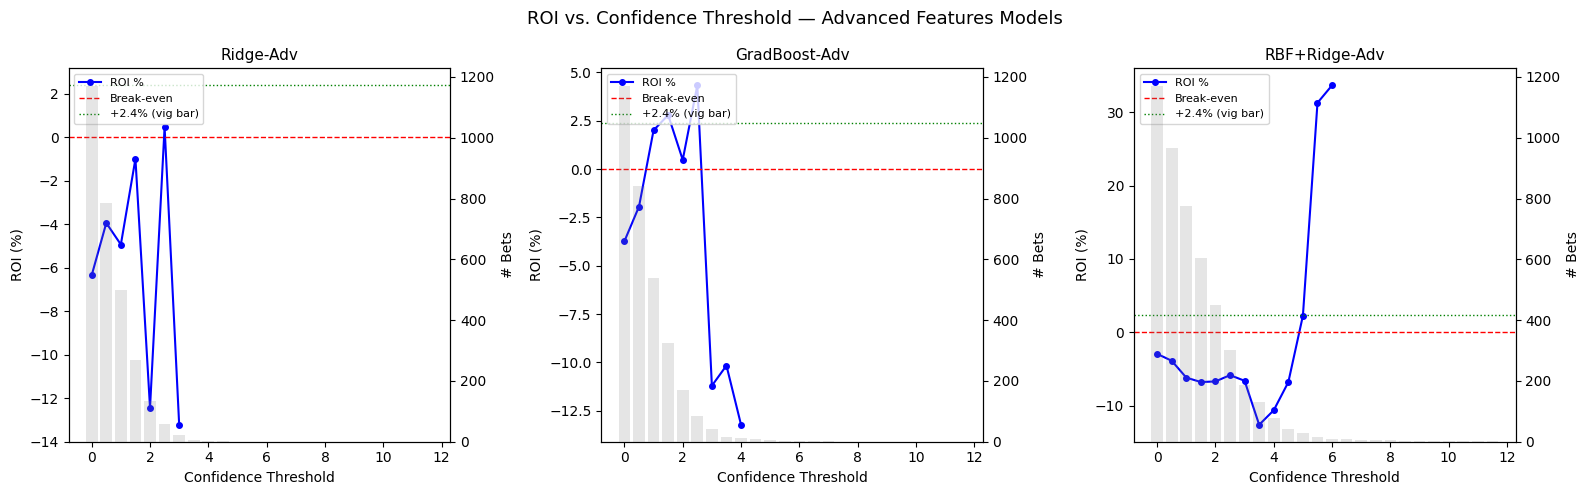

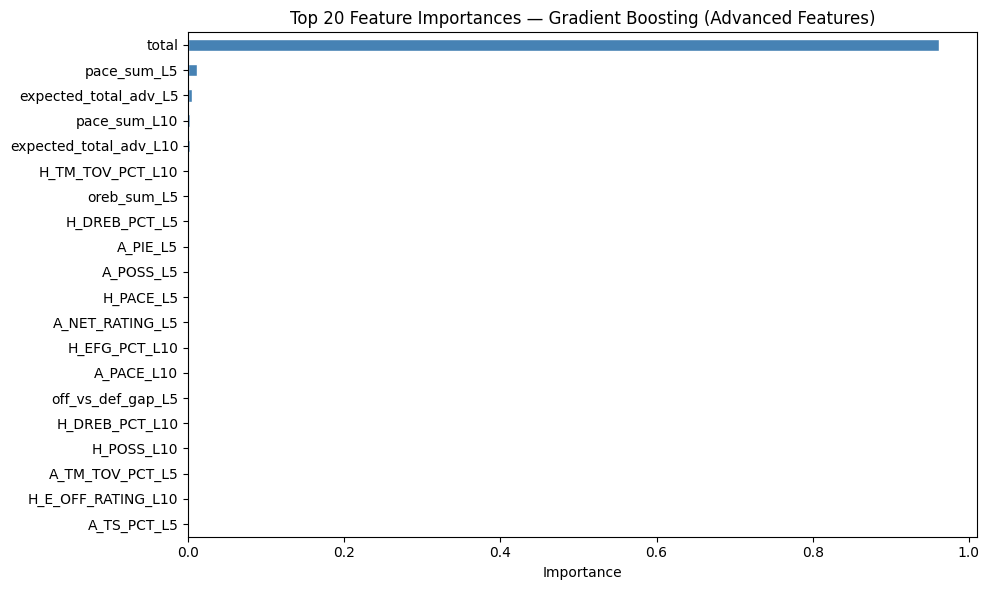


Top 20 features:
total                     0.962058
pace_sum_L5               0.011134
expected_total_adv_L5     0.005105
pace_sum_L10              0.002765
expected_total_adv_L10    0.002298
H_TM_TOV_PCT_L10          0.001039
oreb_sum_L5               0.000816
H_DREB_PCT_L5             0.000803
A_PIE_L5                  0.000769
A_POSS_L5                 0.000675
H_PACE_L5                 0.000672
A_NET_RATING_L5           0.000612
H_EFG_PCT_L10             0.000580
A_PACE_L10                0.000557
off_vs_def_gap_L5         0.000551
H_DREB_PCT_L10            0.000501
H_POSS_L10                0.000496
A_TM_TOV_PCT_L5           0.000470
H_E_OFF_RATING_L10        0.000467
A_TS_PCT_L5               0.000446

SUMMARY — All Models at Threshold = 0 (All Bets)
  Ridge-Adv            | RMSE=17.697 | Acc=49.1% | ROI=-6.34% | n=1170
  GradBoost-Adv        | RMSE=17.667 | Acc=50.4% | ROI=-3.73% | n=1170
  RBF+Ridge-Adv        | RMSE=17.787 | Acc=50.9% | ROI=-2.91% | n=1170


In [18]:
# ============================================================
# CELL 8: Threshold Sweep & Feature Importance
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(0, 12, 0.5)

# ── Threshold Sweep Plot ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, results.items()):
    rois, ns = [], []
    for t in thresholds:
        gap  = np.abs(y_pred - vegas_test)
        mask = gap > t
        n    = mask.sum()
        if n < 10:
            rois.append(np.nan); ns.append(n)
            continue
        wins = np.sum((y_pred[mask] > vegas_test[mask]) == (y_test[mask] > vegas_test[mask]))
        roi  = (wins * 100/110 - (n - wins)) / n
        rois.append(roi * 100); ns.append(n)

    ax2 = ax.twinx()
    ax.plot(thresholds, rois, 'b-o', ms=4, label='ROI %')
    ax2.bar(thresholds, ns, alpha=0.2, color='gray', width=0.4, label='# Bets')
    ax.axhline(0, color='red', linestyle='--', lw=1, label='Break-even')
    ax.axhline(2.4, color='green', linestyle=':', lw=1, label='+2.4% (vig bar)')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('ROI (%)')
    ax2.set_ylabel('# Bets')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('ROI vs. Confidence Threshold — Advanced Features Models', fontsize=13)
plt.tight_layout()
plt.savefig('Images/threshold_sweep_advanced_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gradient Boosting Feature Importance ──
feat_imp = pd.Series(gb_best.feature_importances_, index=feature_cols)
top20 = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Gradient Boosting (Advanced Features)', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('Images/feature_importance_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 20 features:")
print(top20.to_string())

# ── Summary Table ──
print("\n" + "="*70)
print("SUMMARY — All Models at Threshold = 0 (All Bets)")
print("="*70)
for name, y_pred in results.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    wins = np.sum((y_pred > vegas_test) == (y_test > vegas_test))
    n    = len(y_test)
    acc  = wins / n
    roi  = (wins * 100/110 - (n - wins)) / n
    print(f"  {name:20s} | RMSE={rmse:.3f} | Acc={acc:.1%} | ROI={roi:+.2%} | n={n}")